# 🚂 Indian Railways Train Dataset — EDA Notebook
**Dataset:** `Train_Data.csv` | 8,366 rows × 10 columns  
**Goal:** Exploratory Data Analysis covering hub analysis, route efficiency, frequency, class availability, and departure patterns.

---

## 🚆 IRCTC Operations Analytics — Problem Statements

### 🔹 PS-1: Network Hub Identification

* Identify stations acting as major hubs based on **combined origination + termination counts**
* Analyze how station connectivity correlates with **geographic spread**
* Detect **centralized vs distributed network patterns**

---

### 🔹 PS-2: Route Efficiency Analysis

* Calculate **average speed = distance / journey time**
* Identify **fastest and slowest routes**
* Analyze whether **longer routes are proportionally faster or slower**

---

### 🔹 PS-3: Service Frequency & Coverage Gaps

* Identify station pairs with **< 3 trains/week**
* Compare **weekday vs weekend service availability**
* Detect **underserved routes and scheduling blind spots**

---

### 🔹 PS-4: Class Availability & Passenger Equity

* Calculate % of trains offering:

  * Sleeper (SL)
  * AC Classes (1A / 2A / 3A)
  * General (GN)
* Analyze whether **premium classes are concentrated on specific corridors**

---

### 🔹 PS-5: Intermediate Stop Complexity

* Compute **average number of stops per train**
* Analyze correlation between:

  * Stops vs Distance
  * Stops vs Journey Time
* Identify **high-stop vs express route patterns**

---

### 🔹 PS-6: Peak Departure Time Clustering

* Analyze **departure distribution across time slots**
* Identify **morning/evening peak congestion**
* Detect **overloaded scheduling windows**


## 1. Setup & Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Aesthetics
sns.set_theme(style="whitegrid", palette="Blues_d", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load & Inspect Data

In [11]:
df = pd.read_csv(r"C:\Users\Admin\Documents\Deepak Documents\PROJECTS\IRCTC  Operations Analytics\Python Analysis\Train_Data.csv")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Shape: 8,366 rows × 10 columns


,train_no,train_name,source_station,departure_time,arrival_time,distance,destination_station,days_of_week,classes,intermediate_stops
0,10101,RN MADGAON EXP Train,Ratnagiri,1:40,9:00,239.0,Madgaon,"MON,TUE,WED,THU,FRI,SAT,SUN","1A,2A,3A,CC,FC,SL,2S,3E,GN","Ratnagiri (arr=First,dep=01:40) | Rajapur Road..."
1,10102,MADGAON RN EXP Train,Madgaon,19:00,1:54,239.0,Ratnagiri,"MON,TUE,WED,THU,FRI,SAT,SUN","1A,2A,3A,CC,FC,SL,2S,3E,GN","Madgaon (arr=First,dep=19:00) | Verna (arr=19:..."
2,10103,MANDOVI EXPRESS,C Shivaji Maharaj T,7:10,19:10,765.0,Madgaon,"MON,TUE,WED,THU,FRI,SAT,SUN","GN,3E,SL,3A,2A,1A","C Shivaji Maharaj T (arr=First,dep=07:10) | Da..."


In [12]:
# Data types and null counts
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
info

,dtype,non_null,null_count,null_pct
train_no,int64,8366,0,0.0
train_name,object,8366,0,0.0
source_station,object,8366,0,0.0
departure_time,object,8366,0,0.0
arrival_time,object,8366,0,0.0
distance,float64,8366,0,0.0
destination_station,object,8366,0,0.0
days_of_week,object,8366,0,0.0
classes,object,8266,100,1.2
intermediate_stops,object,8366,0,0.0


In [13]:
# Basic statistics for numeric columns
df.describe()

,train_no,distance
count,8366.000000,8366.000000
mean,37012.989481,599.845087
std,21891.022594,712.966429
min,10101.000000,2.000000
25%,15707.250000,105.000000
50%,22885.500000,290.000000
75%,57225.750000,795.750000
max,69250.000000,4189.000000


## 3. Data Cleaning & Feature Engineering

In [14]:
# 3.1 Parse departure and arrival times to datetime
def parse_time(t):
    try:
        return pd.to_datetime(t.strip(), format='%H:%M')
    except:
        return pd.NaT

df['dep_dt'] = df['departure_time'].apply(parse_time)
df['arr_dt'] = df['arrival_time'].apply(parse_time)
df['dep_hour'] = df['dep_dt'].dt.hour

print("Time parsing done.")
print(f"Unparseable departure times: {df['dep_dt'].isna().sum()}")
print(f"Unparseable arrival times:   {df['arr_dt'].isna().sum()}")

Time parsing done.
Unparseable departure times: 0
Unparseable arrival times:   0


In [15]:
# 3.2 Calculate approximate stop count from intermediate_stops column
df['stop_count'] = df['intermediate_stops'].apply(
    lambda x: len(str(x).split('|')) if pd.notna(x) else 0
)
print("Stop count distribution:")
print(df['stop_count'].describe().round(1))

Stop count distribution:
count    8366.0
mean       21.2
std        14.1
min         2.0
25%        11.0
50%        18.0
75%        28.0
max       119.0
Name: stop_count, dtype: float64


In [16]:
# 3.3 Count days of operation per train
df['days_count'] = df['days_of_week'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)
df['is_daily'] = df['days_count'] == 7
print(f"Daily trains: {df['is_daily'].sum():,} ({df['is_daily'].mean()*100:.1f}%)")

Daily trains: 7,861 (94.0%)


In [17]:
# 3.4 Route category based on distance
bins = [0, 99, 499, 1499, 5000]
labels = ['Short (<100 km)', 'Medium (100–499 km)', 'Long (500–1499 km)', 'Very Long (1500+ km)']

df['route_cat'] = pd.cut(df['distance'], bins=bins, labels=labels)


# 3.5 Departure time slot
def time_slot(h):
    if   4  <= h <= 7:  return 'Early Morning (04–07)'
    elif 8  <= h <= 11: return 'Morning (08–11)'
    elif 12 <= h <= 15: return 'Afternoon (12–15)'
    elif 16 <= h <= 19: return 'Evening (16–19)'
    elif 20 <= h <= 23: return 'Night (20–23)'
    else:               return 'Late Night (00–03)'


df['dep_slot'] = df['dep_hour'].apply(
    lambda h: time_slot(h) if pd.notna(h) else 'Unknown'
)

print("Feature engineering complete.")

df[['train_no','distance','route_cat','days_count','is_daily','dep_hour','dep_slot','stop_count']].head()

Feature engineering complete.


,train_no,distance,route_cat,days_count,is_daily,dep_hour,dep_slot,stop_count
0,10101,239.0,Medium (100–499 km),7,True,1,Late Night (00–03),14
1,10102,239.0,Medium (100–499 km),7,True,19,Evening (16–19),14
2,10103,765.0,Long (500–1499 km),7,True,7,Early Morning (04–07),20
3,10104,765.0,Long (500–1499 km),7,True,9,Morning (08–11),20
4,10105,613.0,Long (500–1499 km),7,True,6,Early Morning (04–07),36


## 4. Station Hub Analysis
*Which stations are the biggest rail hubs?*

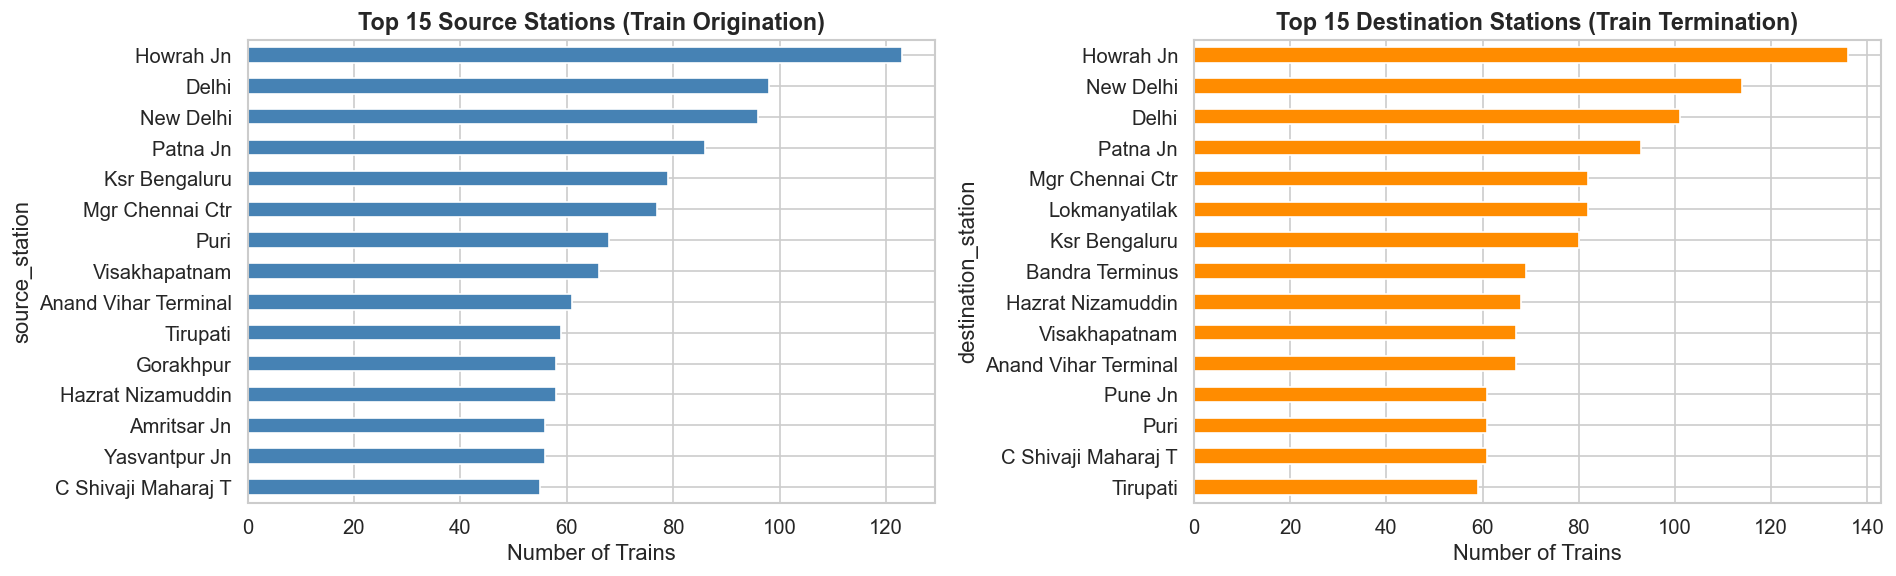

In [18]:
# Top 15 source stations
top_sources = df['source_station'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_sources.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Source Stations (Train Origination)')
axes[0].set_xlabel('Number of Trains')

top_dest = df['destination_station'].value_counts().head(15)
top_dest.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Destination Stations (Train Termination)')
axes[1].set_xlabel('Number of Trains')

plt.tight_layout()
plt.show()

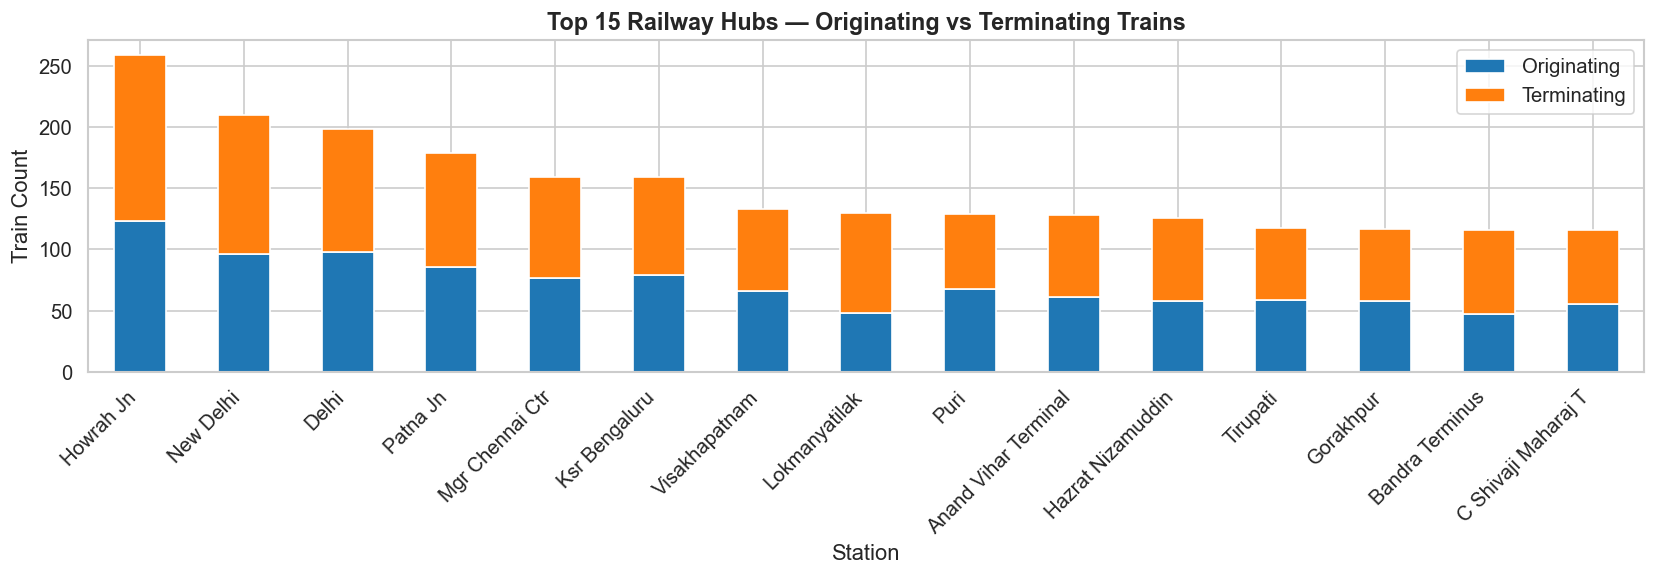

                      originating  terminating  hub_score
Howrah Jn                   123.0        136.0      259.0
New Delhi                    96.0        114.0      210.0
Delhi                        98.0        101.0      199.0
Patna Jn                     86.0         93.0      179.0
Mgr Chennai Ctr              77.0         82.0      159.0
Ksr Bengaluru                79.0         80.0      159.0
Visakhapatnam                66.0         67.0      133.0
Lokmanyatilak                48.0         82.0      130.0
Puri                         68.0         61.0      129.0
Anand Vihar Terminal         61.0         67.0      128.0


In [19]:
# Combined hub score
src = df['source_station'].value_counts().rename('originating')
dst = df['destination_station'].value_counts().rename('terminating')
hub = pd.concat([src, dst], axis=1).fillna(0)
hub['hub_score'] = hub['originating'] + hub['terminating']
hub = hub.sort_values('hub_score', ascending=False).head(15)

hub[['originating','terminating']].plot(
    kind='bar', figsize=(14, 5), stacked=True,
    color=['#1f77b4','#ff7f0e'], edgecolor='white'
)
plt.title('Top 15 Railway Hubs — Originating vs Terminating Trains')
plt.xlabel('Station')
plt.ylabel('Train Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Originating','Terminating'])
plt.tight_layout()
plt.show()

print(hub.head(10))

## 5. Distance & Route Category Analysis
*How are routes distributed by distance?*

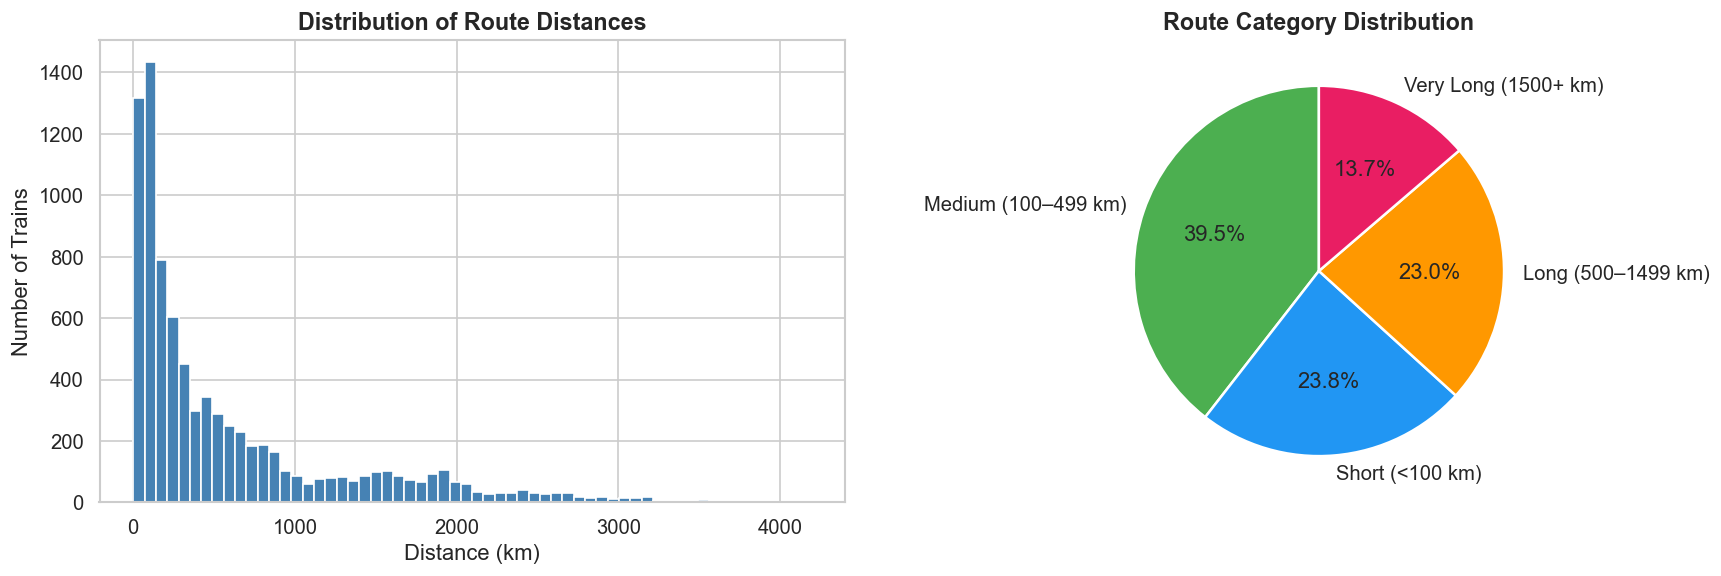

Distance stats by category:
                      count     min    mean     max
route_cat                                          
Short (<100 km)        1989     2.0    57.0    99.0
Medium (100–499 km)    3303   100.0   247.2   499.0
Long (500–1499 km)     1927   500.0   866.6  1499.0
Very Long (1500+ km)   1147  1500.0  2108.5  4189.0


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of distances
axes[0].hist(df['distance'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Route Distances')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Number of Trains')

# Route category pie chart
cat_counts = df['route_cat'].value_counts()
colors = ['#4CAF50','#2196F3','#FF9800','#E91E63']
cat_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                colors=colors, startangle=90,
                wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Route Category Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Distance stats by category:")
print(df.groupby('route_cat')['distance'].agg(['count','min','mean','max']).round(1))

## 6. Ticket Class Availability Analysis
*Which classes are offered across the network?*

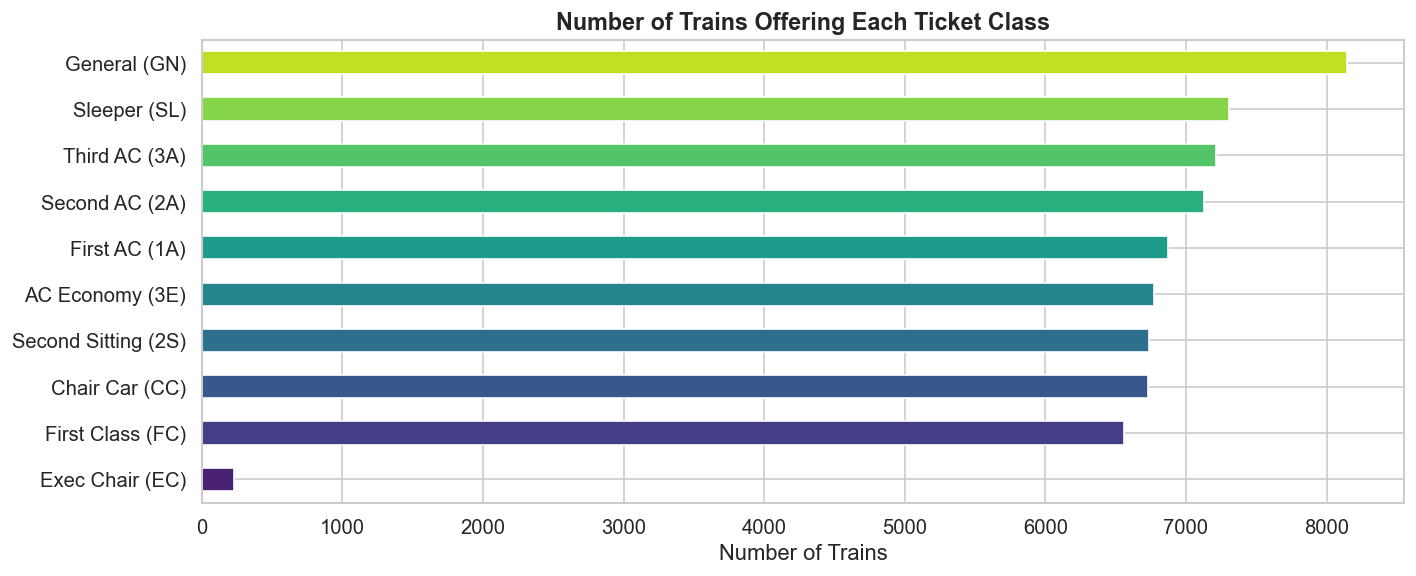


Class coverage %:
  General (GN)             : 8,147  (97.4%)
  Sleeper (SL)             : 7,304  (87.3%)
  Third AC (3A)            : 7,215  (86.2%)
  Second AC (2A)           : 7,129  (85.2%)
  First AC (1A)            : 6,869  (82.1%)
  AC Economy (3E)          : 6,776  (81.0%)
  Second Sitting (2S)      : 6,735  (80.5%)
  Chair Car (CC)           : 6,728  (80.4%)
  First Class (FC)         : 6,560  (78.4%)
  Exec Chair (EC)          :   228  (2.7%)


In [21]:
classes_list = ['1A','2A','3A','SL','CC','2S','GN','3E','EC','FC']
class_labels = ['First AC (1A)','Second AC (2A)','Third AC (3A)','Sleeper (SL)',
                'Chair Car (CC)','Second Sitting (2S)','General (GN)',
                'AC Economy (3E)','Exec Chair (EC)','First Class (FC)']

class_df_filled = df['classes'].fillna('')
counts = {lbl: class_df_filled.str.contains(cls).sum()
          for cls, lbl in zip(classes_list, class_labels)}
class_series = pd.Series(counts).sort_values(ascending=True)

class_series.plot(kind='barh', figsize=(12, 5),
                  color=sns.color_palette('viridis', len(class_series)))
plt.title('Number of Trains Offering Each Ticket Class')
plt.xlabel('Number of Trains')
plt.tight_layout()
plt.show()

print("\nClass coverage %:")
for k, v in sorted(counts.items(), key=lambda x: -x[1]):
    pct = v / len(df) * 100
    print(f"  {k:25s}: {v:5,}  ({pct:.1f}%)")

## 7. Service Frequency Analysis
*How many days per week do trains run?*

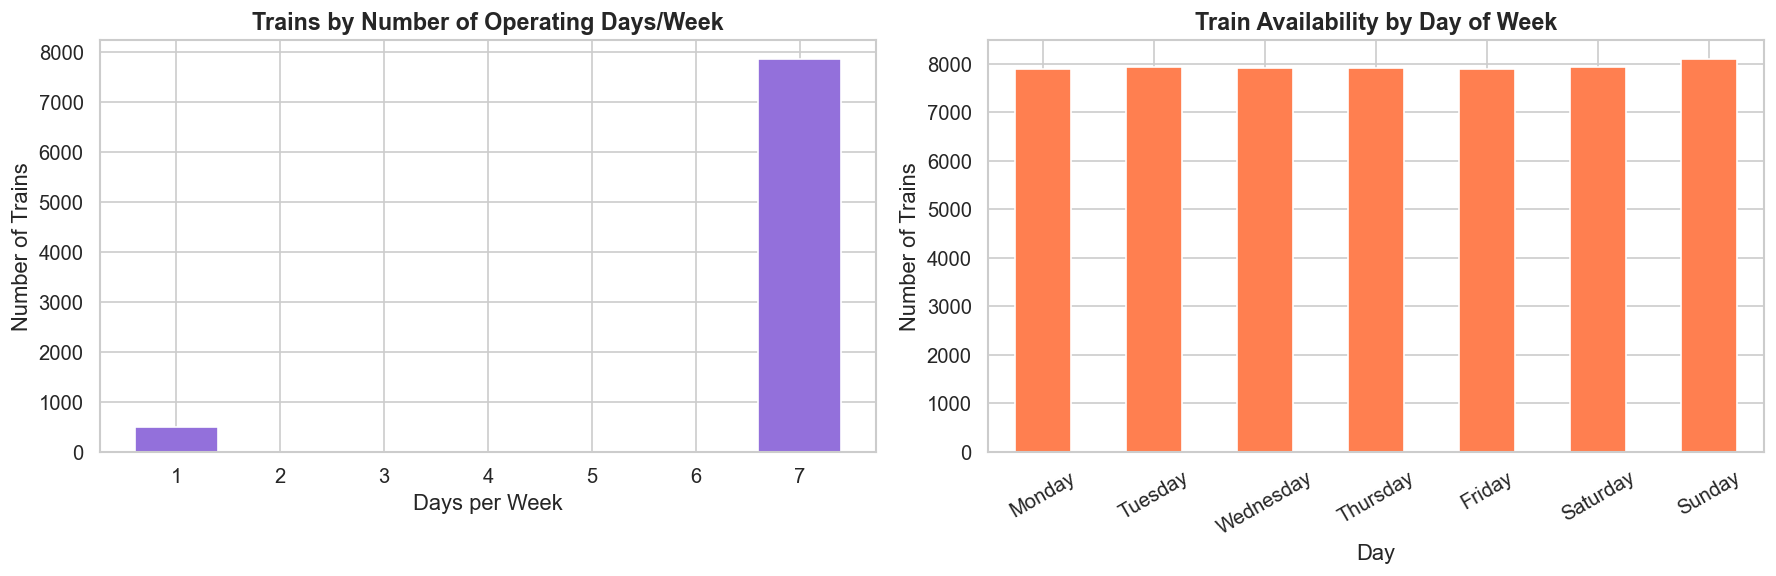

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Days of operation distribution
days_dist = df['days_count'].value_counts().sort_index()
axes[0].bar(days_dist.index, days_dist.values, color='mediumpurple', edgecolor='white')
axes[0].set_title('Trains by Number of Operating Days/Week')
axes[0].set_xlabel('Days per Week')
axes[0].set_ylabel('Number of Trains')
axes[0].set_xticks(range(1, 8))

# Per-day availability
day_map = {'MON':'Monday','TUE':'Tuesday','WED':'Wednesday',
           'THU':'Thursday','FRI':'Friday','SAT':'Saturday','SUN':'Sunday'}
day_counts = {}
for code, name in day_map.items():
    day_counts[name] = df['days_of_week'].str.contains(code, na=False).sum()

pd.Series(day_counts).plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Train Availability by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Trains')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 8. Departure Time Pattern Analysis
*When do most trains depart?*

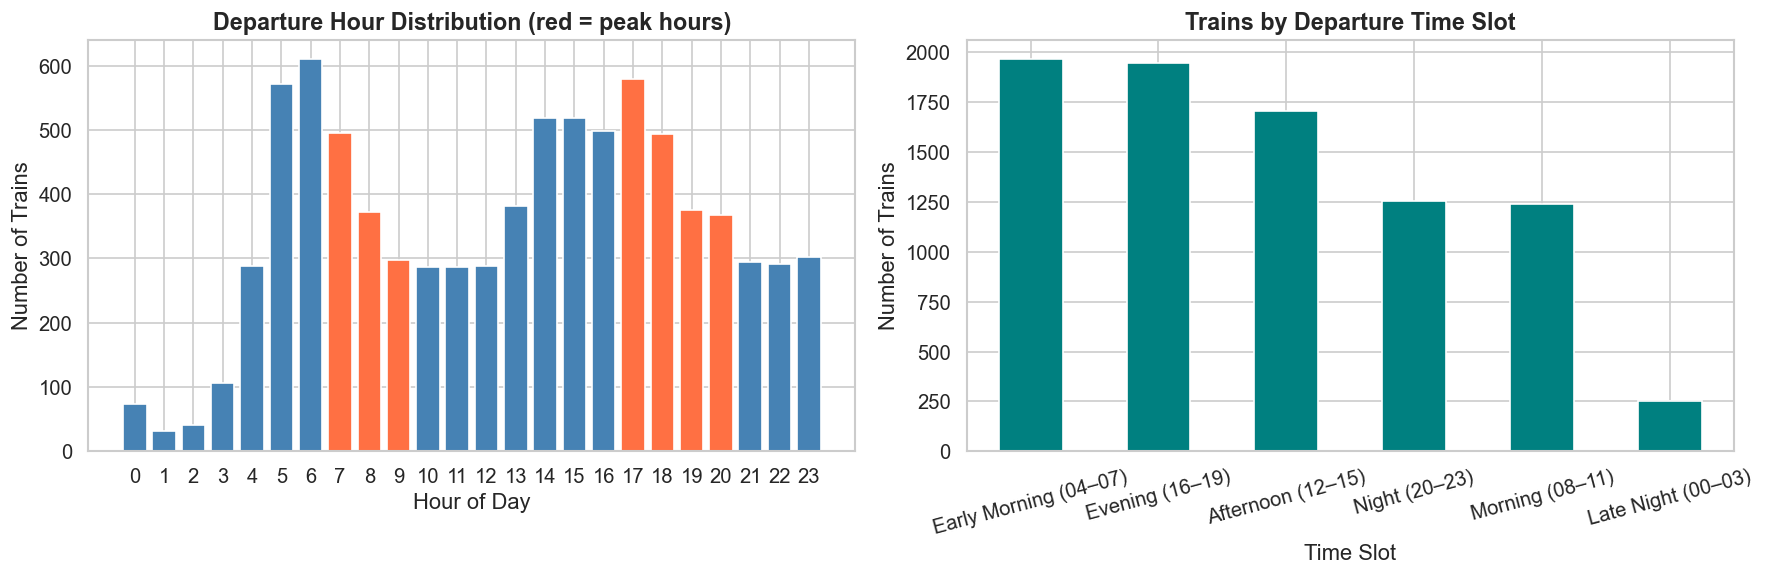

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hourly distribution
hour_counts = df['dep_hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
            color=['#FF7043' if (h >= 7 and h <= 9) or (h >= 17 and h <= 20)
                   else 'steelblue' for h in hour_counts.index],
            edgecolor='white')
axes[0].set_title('Departure Hour Distribution (red = peak hours)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Trains')
axes[0].set_xticks(range(0, 24))

# Time slot distribution
slot_counts = df['dep_slot'].value_counts()
slot_counts.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Trains by Departure Time Slot')
axes[1].set_xlabel('Time Slot')
axes[1].set_ylabel('Number of Trains')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 9. Intermediate Stops Analysis
*How does stop complexity vary with route length?*

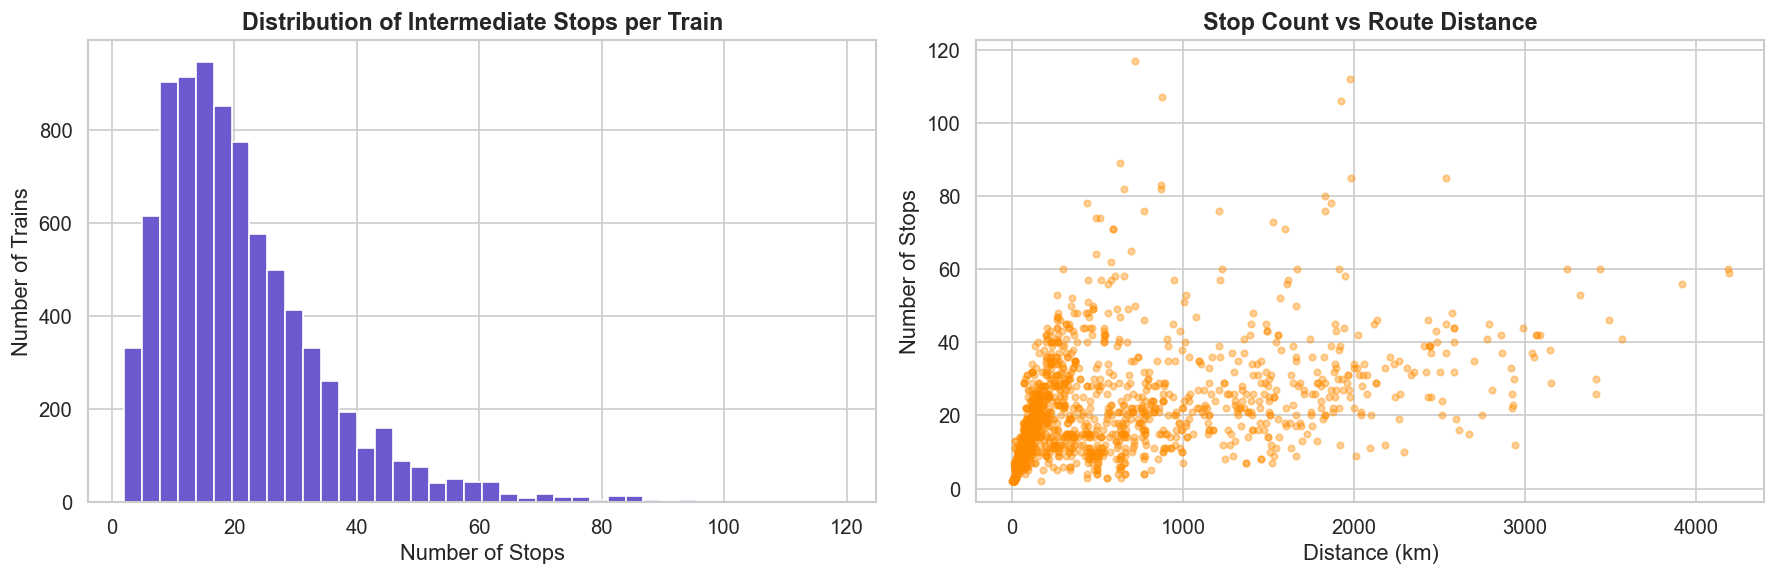


Average stops by route category:
route_cat
Short (<100 km)         10.1
Medium (100–499 km)     22.2
Long (500–1499 km)      24.2
Very Long (1500+ km)    32.5
Name: stop_count, dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stop count distribution
axes[0].hist(df['stop_count'], bins=40, color='slateblue', edgecolor='white')
axes[0].set_title('Distribution of Intermediate Stops per Train')
axes[0].set_xlabel('Number of Stops')
axes[0].set_ylabel('Number of Trains')

# Stops vs Distance scatter (sample 1500 for clarity)
sample = df.sample(1500, random_state=42)
axes[1].scatter(sample['distance'], sample['stop_count'],
                alpha=0.4, s=15, color='darkorange')
axes[1].set_title('Stop Count vs Route Distance')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Number of Stops')

plt.tight_layout()
plt.show()

print("\nAverage stops by route category:")
print(df.groupby('route_cat')['stop_count'].mean().round(1))

## 10. Correlation & Summary Heatmap

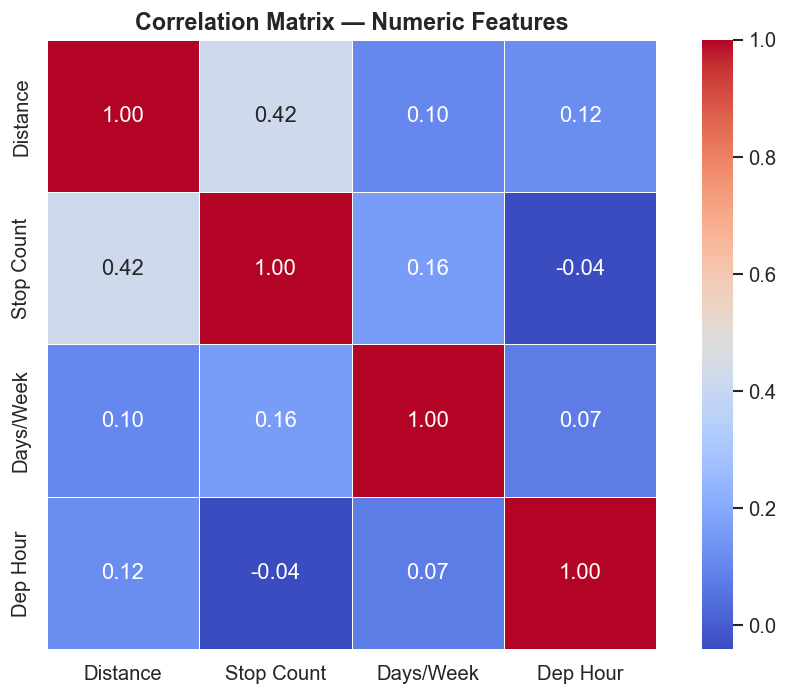

In [25]:
numeric_df = df[['distance','stop_count','days_count','dep_hour']].dropna()
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5,
            xticklabels=['Distance','Stop Count','Days/Week','Dep Hour'],
            yticklabels=['Distance','Stop Count','Days/Week','Dep Hour'])
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

## 11. Key Takeaways & KPIs

In [26]:
print("=" * 55)
print("  INDIAN RAILWAYS DATASET — KEY INSIGHTS")
print("=" * 55)
print(f"  Total trains in dataset   : {len(df):,}")
print(f"  Unique source stations    : {df['source_station'].nunique():,}")
print(f"  Unique destination stns   : {df['destination_station'].nunique():,}")
print(f"  Distance range            : {df['distance'].min():.0f} – {df['distance'].max():.0f} km")
print(f"  Avg route distance        : {df['distance'].mean():.1f} km")
print(f"  Daily trains (7 days/wk)  : {df['is_daily'].sum():,} ({df['is_daily'].mean()*100:.1f}%)")
print(f"  Avg stops per train       : {df['stop_count'].mean():.1f}")
print(f"  Max stops on a route      : {df['stop_count'].max()}")
top_hub = hub.index[0]
print(f"  Biggest rail hub          : {top_hub} ({int(hub.loc[top_hub,'hub_score'])} trains)")
top_src = df['source_station'].value_counts().index[0]
print(f"  Top source station        : {top_src} ({df['source_station'].value_counts().iloc[0]} trains)")
print("=" * 55)

  INDIAN RAILWAYS DATASET — KEY INSIGHTS
  Total trains in dataset   : 8,366
  Unique source stations    : 1,034
  Unique destination stns   : 917
  Distance range            : 2 – 4189 km
  Avg route distance        : 599.8 km
  Daily trains (7 days/wk)  : 7,861 (94.0%)
  Avg stops per train       : 21.2
  Max stops on a route      : 119
  Biggest rail hub          : Howrah Jn (259 trains)
  Top source station        : Howrah Jn (123 trains)


# 🚆 IRCTC Operations Analytics — Key Findings & Recommendations

---

## 🏙️ 1. Infrastructure & Hub Development

**Finding:**
A small number of stations (e.g., Mumbai, Delhi, Kolkata) dominate as hubs with disproportionately high origination + termination counts.

**Recommendation:**

* Invest in **capacity expansion** (additional platforms, signaling upgrades) at top 10 hub stations
* Develop **secondary hubs** in underrepresented regions to decentralize traffic

---

## 📅 2. Fix Weekend Service Gaps

**Finding:**
Many trains operate only on selective weekdays, leaving weekends underserved on certain corridors.

**Recommendation:**

* Introduce **weekend-only express trains** on top 20 OD (origin-destination) pairs running < 4 days/week
* Target **tourism and leisure demand spikes**

---

## 🚉 3. Address Underserved Corridors

**Finding:**
Several source-destination pairs have only **1 train/week**, resulting in poor connectivity.

**Recommendation:**

* Audit all routes with **≤ 2 trains/week**
* Add at least **one additional service** on high-demand corridors
* For low-demand routes, introduce **multi-stop shared/express services**

---

## 🎟️ 4. Improve Passenger Equity in Class Availability

**Finding:**
Premium classes (1A, 2A) are concentrated on long-distance routes, while short/medium routes rely mostly on General (GN).

**Recommendation:**

* Expand **2S (Second Sitting)** and **CC (Chair Car)** options
* Improve **affordability + comfort balance** without full AC deployment

---

## ⏰ 5. Rebalance Departure Scheduling

**Finding:**
Departures are clustered in **early morning and evening**, causing congestion.

**Recommendation:**

* Shift low-priority/freight trains to **off-peak (10 AM – 2 PM)**
* Introduce **mid-morning express trains** on busy routes
* Reduce peak-hour platform load

---

## 🛑 6. Optimize High-Stop Routes

**Finding:**
Some trains have **40+ stops**, significantly increasing journey time.

**Recommendation:**

* Introduce **limited-stop superfast variants** for long routes
* Retain all-stop services for **local accessibility**
* Follow models like **Rajdhani / Shatabdi-type optimization**

---

## 📊 7. Data Quality Improvement

**Finding:**
~100 trains (~1.2%) have missing class information.

**Recommendation:**

* Make class data a **mandatory scheduling field**
* Backfill missing values using **booking system data**
* Improve **forecasting & passenger experience tools**

---

## 🌐 8. Network Connectivity Index

**Finding:**
With 1,034 source and 917 destination stations, many appear only once (low connectivity).

**Recommendation:**

* Create a **Station Connectivity Score = (incoming + outgoing trains)**
* Publish as a public metric
* Prioritize low-score stations in **future railway planning**

---

## 📌 Summary Insight

This analysis highlights a **hub-heavy, unevenly distributed railway network** with clear opportunities in:

* Capacity expansion
* Service balancing
* Passenger equity
* Data-driven planning

---
